In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from stylegan2_core import StyleGAN2Generator, LATENT_DIM

tf.random.set_seed(0)
gen = StyleGAN2Generator()


In [2]:
def slerp(a, b, t):
    a_n = a / (tf.norm(a, axis=-1, keepdims=True) + 1e-8)
    b_n = b / (tf.norm(b, axis=-1, keepdims=True) + 1e-8)
    dot = tf.reduce_sum(a_n * b_n, axis=-1, keepdims=True)
    theta = tf.acos(tf.clip_by_value(dot, -1.0, 1.0))
    sin_theta = tf.sin(theta) + 1e-8
    coef_a = tf.sin((1 - t) * theta) / sin_theta
    coef_b = tf.sin(t * theta) / sin_theta
    return coef_a * a + coef_b * b

def lerp(a, b, t):
    return (1 - t) * a + t * b


In [3]:
z1 = tf.random.normal((1, LATENT_DIM))
z2 = tf.random.normal((1, LATENT_DIM))
w1 = gen.mapping(z1)
w2 = gen.mapping(z2)

ts = np.linspace(0, 1, 8)


In [4]:
z_frames = tf.concat([slerp(z1, z2, t) for t in ts], axis=0)
z_space_imgs = gen(z_frames)[-1]


In [5]:
w_frames = tf.concat([lerp(w1, w2, t) for t in ts], axis=0)

def generate_from_w(gen_model, w, batch_size):
    x = tf.tile(gen_model.const_input, [batch_size, 1, 1, 1])
    for block in gen_model.blocks:
        x, rgb = block(x, w)
    return rgb

w_space_imgs = generate_from_w(gen, w_frames, len(ts))


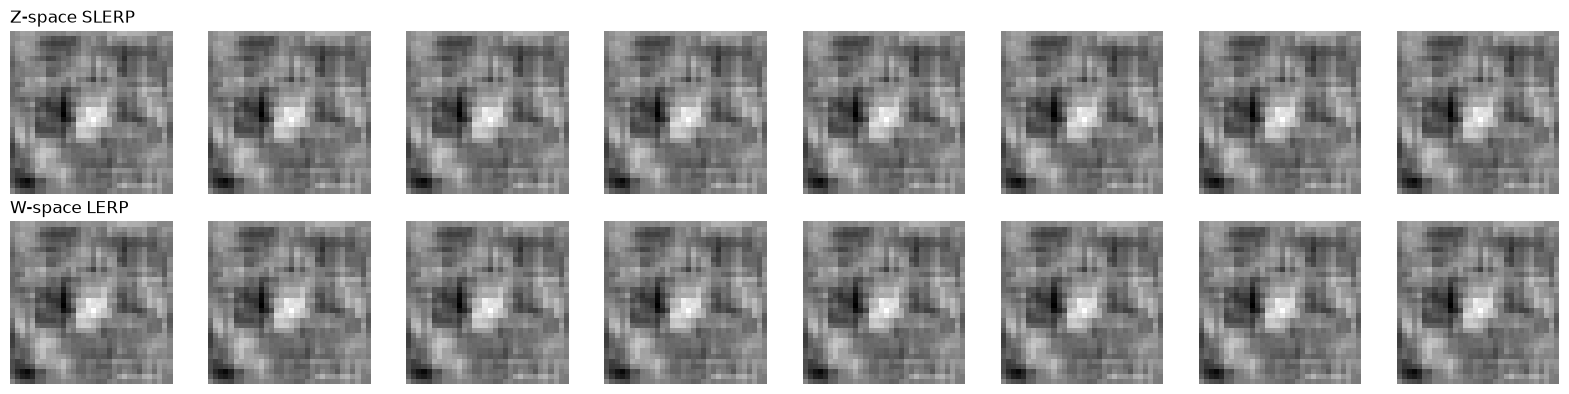

In [6]:
fig, axes = plt.subplots(2, len(ts), figsize=(2 * len(ts), 4))
for i in range(len(ts)):
    axes[0, i].imshow((z_space_imgs[i, ..., 0].numpy() + 1) / 2, cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow((w_space_imgs[i, ..., 0].numpy() + 1) / 2, cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_title("Z-space SLERP", loc="left")
axes[1, 0].set_title("W-space LERP", loc="left")
plt.tight_layout()
plt.show()


In [7]:
z_frame_diffs = tf.reduce_mean(tf.abs(z_space_imgs[1:] - z_space_imgs[:-1]), axis=[1, 2, 3])
w_frame_diffs = tf.reduce_mean(tf.abs(w_space_imgs[1:] - w_space_imgs[:-1]), axis=[1, 2, 3])
print("Z-space frame-to-frame change:", z_frame_diffs.numpy())
print("W-space frame-to-frame change:", w_frame_diffs.numpy())
print("Z-space std of changes (smoothness):", float(tf.math.reduce_std(z_frame_diffs)))
print("W-space std of changes (smoothness):", float(tf.math.reduce_std(w_frame_diffs)))


Z-space frame-to-frame change: [0.00034876 0.00031418 0.00035858 0.00031887 0.00036208 0.00038709
 0.00033548]
W-space frame-to-frame change: [0.00016821 0.00016823 0.00016811 0.0001683  0.00016845 0.00016859
 0.00016856]
Z-space std of changes (smoothness): 2.3817841793061234e-05
W-space std of changes (smoothness): 1.704801064761341e-07
